# Session 02: Machine Learning vs Deep Learning - Hands-On Practice

This notebook breaks down the ML vs DL workflow into digestible steps. We will:
1. Generate synthetic data
2. Explore supervised learning with Scikit-learn
3. Build a deep learning model with PyTorch
4. Understand each step of the training process

Run -> `poetry add torch scikit-learn`

## Part 1: Data Generation

Let's start by generating a synthetic dataset for binary classification.

In [1]:
from sklearn.datasets import make_classification

# Generate a synthetic classification dataset
X, y = make_classification(
    n_samples=1000,      # Total number of samples
    n_features=10,       # Number of features per sample
    n_classes=2,         # Binary classification (2 classes)
    random_state=42      # For reproducibility
)

print("Dataset shape:")
print(f"  Features (X): {X.shape}")
print(f"  Labels (y): {y.shape}")
print(f"\nClass distribution: {sum(y)} positive samples, {len(y) - sum(y)} negative samples")

Dataset shape:
  Features (X): (1000, 10)
  Labels (y): (1000,)

Class distribution: 499 positive samples, 501 negative samples


## Part 2: Train-Test Split

Split the dataset into training and testing sets to evaluate model generalization.

In [2]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Testing set: {X_test.shape[0]} samples")

Train-Test Split:
  Training set: 800 samples
  Testing set: 200 samples


## Part 3: Machine Learning - Random Forest Classifier

Machine Learning typically requires **manual feature engineering**. We train a Random Forest model, which makes decisions based on the input features without learning hierarchical representations.

### Understanding Decision Trees and Random Forests

**Decision Tree:**
A decision tree is a simple model that makes decisions by asking a series of yes/no questions about the features. It splits the data recursively based on feature values to create a tree-like structure. Each split is chosen to best separate the classes.

![Decision Tree Structure - showing hierarchical splits and leaf nodes for binary classification](Decision-Tree-Structure.png)

Example decision path:
```
Is feature_1 > 0.5?
├─ Yes: Is feature_2 > 0.3?
│       ├─ Yes: Predict class 1
│       └─ No: Predict class 0
└─ No: Is feature_3 > 0.7?
        ├─ Yes: Predict class 1
        └─ No: Predict class 0
```

**Random Forest:**
A random forest is an ensemble (collection) of multiple decision trees. Instead of training one tree, we train many trees on random subsets of the data. Each tree votes on the prediction, and the majority vote wins. This voting process reduces overfitting and improves generalization.

![Random Forest Ensemble - showing multiple decision trees voting together for final prediction](Random-Forest-Ensemble.webp)

**Key Differences:**

| Aspect | Decision Tree | Random Forest |
|--------|---------------|---------------|
| **Structure** | Single tree | Multiple trees (ensemble) |
| **Overfitting** | High risk of overfitting | Low (voting reduces overfitting) |
| **Training Data** | Uses all data | Each tree uses random subset |
| **Prediction** | One tree decides | Multiple trees vote |
| **Stability** | Can be unstable with small data changes | More stable and robust |
| **Interpretability** | Easy to visualize and understand | Harder to interpret (many trees) |
| **Accuracy** | Often lower | Usually higher |

In our code below, we use a Random Forest with 100 trees (`n_estimators=100`), which means 100 separate decision trees working together to make predictions.

In [3]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Initialize the classifier
print("Step 1: Initialize the model")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
print(f"  Model: {rf_model}")

# Step 2: Train (fit) the model
print("\nStep 2: Train the model")
rf_model.fit(X_train, y_train)
print("  Model training complete!")

# Step 3: Make predictions on training data
print("\nStep 3: Predictions on training set")
y_train_pred = rf_model.predict(X_train)
print(f"  First 5 predictions: {y_train_pred[:5]}")
print(f"  First 5 actual labels: {y_train[:5]}")

Step 1: Initialize the model
  Model: RandomForestClassifier(random_state=42)

Step 2: Train the model
  Model training complete!

Step 3: Predictions on training set
  First 5 predictions: [1 1 0 1 0]
  First 5 actual labels: [1 1 0 1 0]


### Evaluate ML Model

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predict on test set
y_test_pred = rf_model.predict(X_test)

# Calculate metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print("Random Forest Performance:")
print(f"  Training Accuracy: {train_acc:.4f}")
print(f"  Testing Accuracy:  {test_acc:.4f}")
print(f"  Precision:         {precision:.4f}")
print(f"  Recall:            {recall:.4f}")

Random Forest Performance:
  Training Accuracy: 1.0000
  Testing Accuracy:  0.8800
  Precision:         0.9143
  Recall:            0.8649


## Part 4: Deep Learning - Neural Network with PyTorch

Deep Learning learns hierarchical representations directly from raw data. Here we build a neural network that learns non-linear transformations through multiple layers.

### Step 1: Import PyTorch and Prepare Data

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("PyTorch Tensors Created:")
print(f"  X_train shape: {X_train_tensor.shape}")
print(f"  y_train shape: {y_train_tensor.shape}")

# Create a DataLoader to batch the data
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"\nDataLoader created with batch_size=32")
print(f"  Number of batches: {len(train_loader)}")

PyTorch Tensors Created:
  X_train shape: torch.Size([800, 10])
  y_train shape: torch.Size([800, 1])

DataLoader created with batch_size=32
  Number of batches: 25


### Step 2: Define the Neural Network Architecture

We use `nn.Sequential()` for a simpler, more concise way to define the network. This approach stacks layers directly without needing a custom class. We output 2 class logits with softmax activation for multi-class scalability.

In [ ]:
[32, 10] @ [10, 50] -> [16, 32] @ [32, 50] -> [2, 16] @ [16, 50] -> [2, 50]
[2, 16] @ [16, 32] @ [32, 10] @ [10, 50] -> [2, 50]
[2, 10] @ [10, 50] -> [2, 50]

In [10]:
# Define the neural network using nn.Sequential with OrderedDict
# This allows us to access layers by name for better debugging and introspection
# Architecture:
# - Input: 10 features
# - Hidden layer 1: 32 neurons + ReLU activation
# - Hidden layer 2: 16 neurons + ReLU activation
# - Output: 2 neurons (for 2 classes: binary classification)

from collections import OrderedDict

model = nn.Sequential(OrderedDict([
    ('fc1', nn.Linear(10, 32)),   # Input layer: 10 -> 32
    ('relu1', nn.ReLU()),                       # Activation: ReLU
    ('fc2', nn.Linear(32, 16)),                 # Hidden layer: 32 -> 16
    ('relu2', nn.ReLU()),                       # Activation: ReLU
    ('fc3', nn.Linear(16, 2))                   # Output layer: 16 -> 2 (2 classes)
]))

print("Neural Network Architecture:")
print(model)
print("\nNote: Output has 2 neurons for 2 classes, scalable to any number of classes")
print("\nAccessing layers by name:")
print(f"  model['fc1']: {model.fc1}")
print(f"  model['relu1']: {model.relu1}")
print(f"  model['fc3']: {model.fc3}")

Neural Network Architecture:
Sequential(
  (fc1): Linear(in_features=10, out_features=32, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=16, out_features=2, bias=True)
)

Note: Output has 2 neurons for 2 classes, scalable to any number of classes

Accessing layers by name:
  model['fc1']: Linear(in_features=10, out_features=32, bias=True)
  model['relu1']: ReLU()
  model['fc3']: Linear(in_features=16, out_features=2, bias=True)


### Step 3: Setup Training Components

Before training, we need:
1. **Loss function**: CrossEntropyLoss combines LogSoftmax and NLLLoss for multi-class classification
2. **Optimizer**: Updates weights based on gradients

In [11]:
# Loss function: CrossEntropyLoss for multi-class classification
# It applies softmax internally, so no need for explicit sigmoid/softmax in the model
criterion = nn.CrossEntropyLoss()
print("Loss Function: CrossEntropyLoss")
print("  Combines softmax activation with negative log likelihood loss")
print("  Ideal for multi-class classification problems")

# Optimizer: Adam with learning rate 0.001
optimizer = optim.Adam(model.parameters(), lr=0.0001)
print("\nOptimizer: Adam")
print("  Updates model weights to minimize loss")
print("  Learning rate: 0.001")

Loss Function: CrossEntropyLoss
  Combines softmax activation with negative log likelihood loss
  Ideal for multi-class classification problems

Optimizer: Adam
  Updates model weights to minimize loss
  Learning rate: 0.001


### Step 4: One Training Epoch - Understanding Forward and Backward Pass

Let's go through ONE epoch (one pass through all data) step by step to understand what happens.

In [15]:
batch_y_long

tensor([1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
        1, 1, 0, 0, 0, 0, 0, 1])

In [21]:
# outputs.shape
import numpy as np

np.arange(32)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [29]:
outputs

tensor([[-0.3747,  0.0451],
        [-0.1803,  0.1557],
        [-0.2856,  0.0673],
        [-0.3233,  0.0313],
        [-0.4241, -0.0472],
        [-0.6087, -0.1438],
        [-0.2640,  0.1823],
        [-0.3773,  0.1824],
        [-0.3129,  0.0903],
        [-0.3916,  0.1473],
        [-0.3765,  0.0739],
        [-0.2971,  0.1853],
        [-0.3427,  0.0812],
        [-0.3641,  0.1043],
        [-0.4354,  0.1582],
        [-0.3220,  0.1366],
        [-0.3207,  0.0612],
        [-0.2902,  0.2263],
        [-0.3341,  0.2244],
        [-0.2984,  0.1500],
        [-0.4502,  0.0315],
        [-0.2229,  0.1837],
        [-0.3912,  0.0421],
        [-0.4039,  0.0467],
        [-0.2465,  0.2423],
        [-0.3343,  0.0547],
        [-0.4772,  0.1970],
        [-0.2966,  0.1266],
        [-0.2926,  0.1450],
        [-0.4165,  0.0803],
        [-0.3944,  0.2022],
        [-0.4792, -0.0151]], grad_fn=<AddmmBackward0>)

In [31]:
softmax(outputs)

C:\Users\Baraa\AppData\Local\Temp\ipykernel_19468\3108265397.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  softmax(outputs)


tensor([[0.3966, 0.6034],
        [0.4168, 0.5832],
        [0.4127, 0.5873],
        [0.4123, 0.5877],
        [0.4069, 0.5931],
        [0.3858, 0.6142],
        [0.3902, 0.6098],
        [0.3636, 0.6364],
        [0.4005, 0.5995],
        [0.3684, 0.6316],
        [0.3893, 0.6107],
        [0.3817, 0.6183],
        [0.3956, 0.6044],
        [0.3850, 0.6150],
        [0.3558, 0.6442],
        [0.3873, 0.6127],
        [0.4057, 0.5943],
        [0.3737, 0.6263],
        [0.3639, 0.6361],
        [0.3898, 0.6102],
        [0.3819, 0.6181],
        [0.3997, 0.6003],
        [0.3933, 0.6067],
        [0.3892, 0.6108],
        [0.3802, 0.6198],
        [0.4040, 0.5960],
        [0.3376, 0.6624],
        [0.3958, 0.6042],
        [0.3923, 0.6077],
        [0.3783, 0.6217],
        [0.3551, 0.6449],
        [0.3860, 0.6140]], grad_fn=<SoftmaxBackward0>)

In [32]:
from torch.nn.functional import softmax 

softmax(outputs)[np.arange(32), batch_y_long]

C:\Users\Baraa\AppData\Local\Temp\ipykernel_19468\3559982831.py:3: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  softmax(outputs)[np.arange(32), batch_y_long]


tensor([0.6034, 0.5832, 0.5873, 0.4123, 0.5931, 0.6142, 0.6098, 0.6364, 0.4005,
        0.6316, 0.3893, 0.3817, 0.6044, 0.3850, 0.3558, 0.6127, 0.5943, 0.3737,
        0.3639, 0.6102, 0.3819, 0.6003, 0.6067, 0.3892, 0.6198, 0.5960, 0.3376,
        0.3958, 0.3923, 0.3783, 0.3551, 0.6140], grad_fn=<IndexBackward0>)

In [35]:
tmp_mat = softmax(outputs)[np.arange(32), batch_y_long]


C:\Users\Baraa\AppData\Local\Temp\ipykernel_19468\1554960244.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  tmp_mat = softmax(outputs)[np.arange(32), batch_y_long]


In [36]:
tmp_mat = tmp_mat.detach().numpy()
tmp_mat

array([0.6034398 , 0.5832178 , 0.58730197, 0.41227606, 0.59313244,
       0.61418205, 0.6097565 , 0.6363851 , 0.40053958, 0.6315669 ,
       0.38926592, 0.38169348, 0.6044165 , 0.38499838, 0.35582325,
       0.61269575, 0.5943287 , 0.3736834 , 0.36388198, 0.6102399 ,
       0.38185155, 0.60026556, 0.6066588 , 0.38922793, 0.61982095,
       0.59602267, 0.33755544, 0.3957512 , 0.39231816, 0.3782758 ,
       0.35511935, 0.6139902 ], dtype=float32)

In [37]:
tmp_mat[0] = 1
tmp_mat[1] = 0.0001

In [38]:
tmp_mat

array([1.0000000e+00, 9.9999997e-05, 5.8730197e-01, 4.1227606e-01,
       5.9313244e-01, 6.1418205e-01, 6.0975653e-01, 6.3638508e-01,
       4.0053958e-01, 6.3156688e-01, 3.8926592e-01, 3.8169348e-01,
       6.0441649e-01, 3.8499838e-01, 3.5582325e-01, 6.1269575e-01,
       5.9432870e-01, 3.7368339e-01, 3.6388198e-01, 6.1023992e-01,
       3.8185155e-01, 6.0026556e-01, 6.0665882e-01, 3.8922793e-01,
       6.1982095e-01, 5.9602267e-01, 3.3755544e-01, 3.9575121e-01,
       3.9231816e-01, 3.7827581e-01, 3.5511935e-01, 6.1399019e-01],
      dtype=float32)

In [39]:
np.log(tmp_mat)

array([ 0.        , -9.2103405 , -0.5322162 , -0.8860621 , -0.52233756,
       -0.4874639 , -0.49469554, -0.45195144, -0.91494274, -0.45955142,
       -0.94349253, -0.9631374 , -0.50349176, -0.9545162 , -1.0333211 ,
       -0.48988676, -0.52032274, -0.9843464 , -1.0109258 , -0.49390307,
       -0.9627234 , -0.5103831 , -0.49978873, -0.94359016, -0.47832462,
       -0.51747656, -1.0860255 , -0.9269695 , -0.9356821 , -0.9721317 ,
       -1.0353013 , -0.48777634], dtype=float32)

In [43]:
np.mean(-np.log(softmax(outputs)[np.arange(32), batch_y_long].detach().numpy()))

C:\Users\Baraa\AppData\Local\Temp\ipykernel_19468\345094766.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  np.mean(-np.log(softmax(outputs)[np.arange(32), batch_y_long].detach().numpy()))


np.float32(0.7202201)

In [71]:
batch_X[1]

tensor([-0.0341, -0.1275, -0.1690,  1.5112, -0.1891,  0.9217,  0.4667, -0.0121,
        -0.4161, -1.4512])

In [ ]:
from torch.nn.functional import dropout

dropout(batch_X, 0.1)[1]

tensor([-0., -0., -0., 0., -0., 0., 0., -0., -0., -0.])

In [65]:
# Switch to training mode
model.train()

# Get the first batch manually to illustrate the steps
batch_X, batch_y = next(iter(train_loader))

# Convert labels to long type (required for CrossEntropyLoss)
batch_y_long = batch_y.long().squeeze()

print("=== BATCH INFORMATION ===")
print(f"Batch shape: {batch_X.shape} (32 samples, 10 features)")
print(f"Labels shape: {batch_y_long.shape}")
print()

# Step 1: FORWARD PASS
print("Step 1: FORWARD PASS")
print("  Call model(batch_X) to get logits (raw scores)")
outputs = model(batch_X)
print(f"  Output shape: {outputs.shape}")
print(f"  Output values (first 3): {outputs[:3].detach().tolist()}")
print(f"  These are logits (scores) for each class before softmax")
print()

# Step 2: CALCULATE LOSS
print("Step 2: CALCULATE LOSS")
print("  Compare logits with actual labels using CrossEntropyLoss")
print("  CrossEntropyLoss applies softmax internally")
loss = criterion(outputs, batch_y_long)
print(f"  Loss value: {loss.item():.4f}")
print(f"  Lower loss = better predictions")
print()

=== BATCH INFORMATION ===
Batch shape: torch.Size([32, 10]) (32 samples, 10 features)
Labels shape: torch.Size([32])

Step 1: FORWARD PASS
  Call model(batch_X) to get logits (raw scores)
  Output shape: torch.Size([32, 2])
  Output values (first 3): [[-0.6395272016525269, -0.15273773670196533], [-0.43996018171310425, 0.01951749622821808], [-0.27704280614852905, 0.1057112067937851]]
  These are logits (scores) for each class before softmax

Step 2: CALCULATE LOSS
  Compare logits with actual labels using CrossEntropyLoss
  CrossEntropyLoss applies softmax internally
  Loss value: 0.6649
  Lower loss = better predictions



In [50]:
model.fc1.weight.shape

torch.Size([32, 10])

In [67]:
model.fc1.weight[0]

tensor([-0.1744,  0.2465,  0.2496, -0.1885, -0.1494, -0.1717, -0.0094,  0.0232,
         0.3033, -0.0961], grad_fn=<SelectBackward0>)

In [56]:
model.fc1.weight[0]

tensor([-0.1743,  0.2464,  0.2497, -0.1884, -0.1493, -0.1718, -0.0095,  0.0231,
         0.3032, -0.0960], grad_fn=<SelectBackward0>)

In [68]:
model.fc1.weight.grad[0]

tensor([ 5.1051e-03, -9.6436e-04,  5.0828e-03,  2.2763e-03,  5.8877e-03,
        -1.0080e-03, -8.1259e-03, -4.1605e-03, -3.7762e-03,  9.4596e-06])

In [66]:
# Step 3: BACKWARD PASS (Gradient Computation)
print("Step 3: BACKWARD PASS")
print("  Clear old gradients")
optimizer.zero_grad()
print("  Gradients cleared!")
print()

print("  Compute gradients (backpropagation)")
loss.backward()
print("  Gradients computed for every parameter!")
print(f"  Gradient norm for fc1: {model.fc1.weight.grad.norm().item():.6f}")
print(f"  Gradient norm for fc2: {model.fc2.weight.grad.norm().item():.6f}")
print(f"  Gradient norm for fc3: {model.fc3.weight.grad.norm().item():.6f}")
print()

# Step 4: WEIGHT UPDATE
print("Step 4: WEIGHT UPDATE")
print("  Update weights using gradients and learning rate")
print("  new_weight = old_weight - learning_rate * gradient")
optimizer.step()
print("  Weights updated!")
print()

Step 3: BACKWARD PASS
  Clear old gradients
  Gradients cleared!

  Compute gradients (backpropagation)
  Gradients computed for every parameter!
  Gradient norm for fc1: 0.068025
  Gradient norm for fc2: 0.148702
  Gradient norm for fc3: 0.061681

Step 4: WEIGHT UPDATE
  Update weights using gradients and learning rate
  new_weight = old_weight - learning_rate * gradient
  Weights updated!



### Step 5: Full Training Loop - Multiple Epochs

In [69]:
import numpy as np

num_epochs, print_interval = 500, 20
print_indices = set(np.linspace(0, num_epochs-1, print_interval, dtype=int))
training_losses = []

print("Starting full training...")
print()

for epoch in range(num_epochs):
    model.train()  # Set to training mode
    epoch_loss = 0.0
    
    # Loop through all batches
    for batch_X, batch_y in train_loader:
        # Convert labels to long type for CrossEntropyLoss
        batch_y_long = batch_y.long().squeeze()
        
        # 1. Forward pass
        outputs = model(batch_X)
        
        # 2. Calculate loss
        loss = criterion(outputs, batch_y_long)
        
        # 3. Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # 4. Update weights
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Average loss for the epoch
    avg_loss = epoch_loss / len(train_loader)
    training_losses.append(avg_loss)
    
    if epoch in print_indices:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Starting full training...

Epoch [1/500], Loss: 0.7301
Epoch [27/500], Loss: 0.4250
Epoch [53/500], Loss: 0.3091
Epoch [79/500], Loss: 0.2938
Epoch [106/500], Loss: 0.2849
Epoch [132/500], Loss: 0.2782
Epoch [158/500], Loss: 0.2723
Epoch [184/500], Loss: 0.2669
Epoch [211/500], Loss: 0.2612
Epoch [237/500], Loss: 0.2559
Epoch [263/500], Loss: 0.2504
Epoch [289/500], Loss: 0.2450
Epoch [316/500], Loss: 0.2393
Epoch [342/500], Loss: 0.2338
Epoch [368/500], Loss: 0.2286
Epoch [394/500], Loss: 0.2234
Epoch [421/500], Loss: 0.2171
Epoch [447/500], Loss: 0.2112
Epoch [473/500], Loss: 0.2052
Epoch [500/500], Loss: 0.1990

Training complete!


### Step 6: Evaluation - Testing the Trained Model

Now we switch to evaluation mode with `model.eval()` and disable gradient computation with `torch.no_grad()` for inference.

In [75]:
print("=== EVALUATION ===")
print()

# Switch to evaluation mode
model.eval()

# No gradient computation during inference (faster, less memory)
with torch.no_grad():
    # Predictions on training set
    train_outputs = model(X_train_tensor)
    train_predictions = torch.argmax(train_outputs, dim=1).numpy()
    
    # Predictions on test set
    test_outputs = model(X_test_tensor)
    test_predictions = torch.argmax(test_outputs, dim=1).numpy()

# Calculate accuracy
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("Neural Network Performance (with 2-class softmax output):")
print(f"  Training Accuracy: {train_accuracy:.4f}")
print(f"  Testing Accuracy:  {test_accuracy:.4f}")
print()

print("Comparison with Random Forest:")
print(f"  RF Training Accuracy: {train_acc:.4f}")
print(f"  RF Testing Accuracy:  {test_acc:.4f}")

=== EVALUATION ===

Neural Network Performance (with 2-class softmax output):
  Training Accuracy: 0.9213
  Testing Accuracy:  0.8500

Comparison with Random Forest:
  RF Training Accuracy: 1.0000
  RF Testing Accuracy:  0.8800


## Part 5: Visualize 

### Training Loss

Let's visualize how the model's loss decreased over epochs, showing that learning happened.

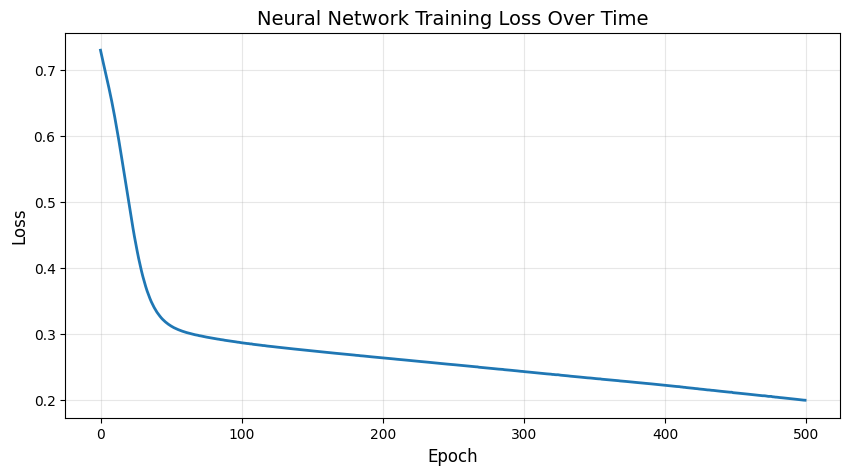

Initial Loss: 0.7301
Final Loss:   0.1990
Loss Reduction: 72.7%


In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(training_losses, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Neural Network Training Loss Over Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial Loss: {training_losses[0]:.4f}")
print(f"Final Loss:   {training_losses[-1]:.4f}")
print(f"Loss Reduction: {(training_losses[0] - training_losses[-1]) / training_losses[0] * 100:.1f}%")

### Decision Boundary

Let's visualize the decision boundary of both models using PCA to reduce the 10D data to 2D.


PCA Explained Variance Ratio: [0.30567768 0.15137305]
Total Variance Explained: 45.7%


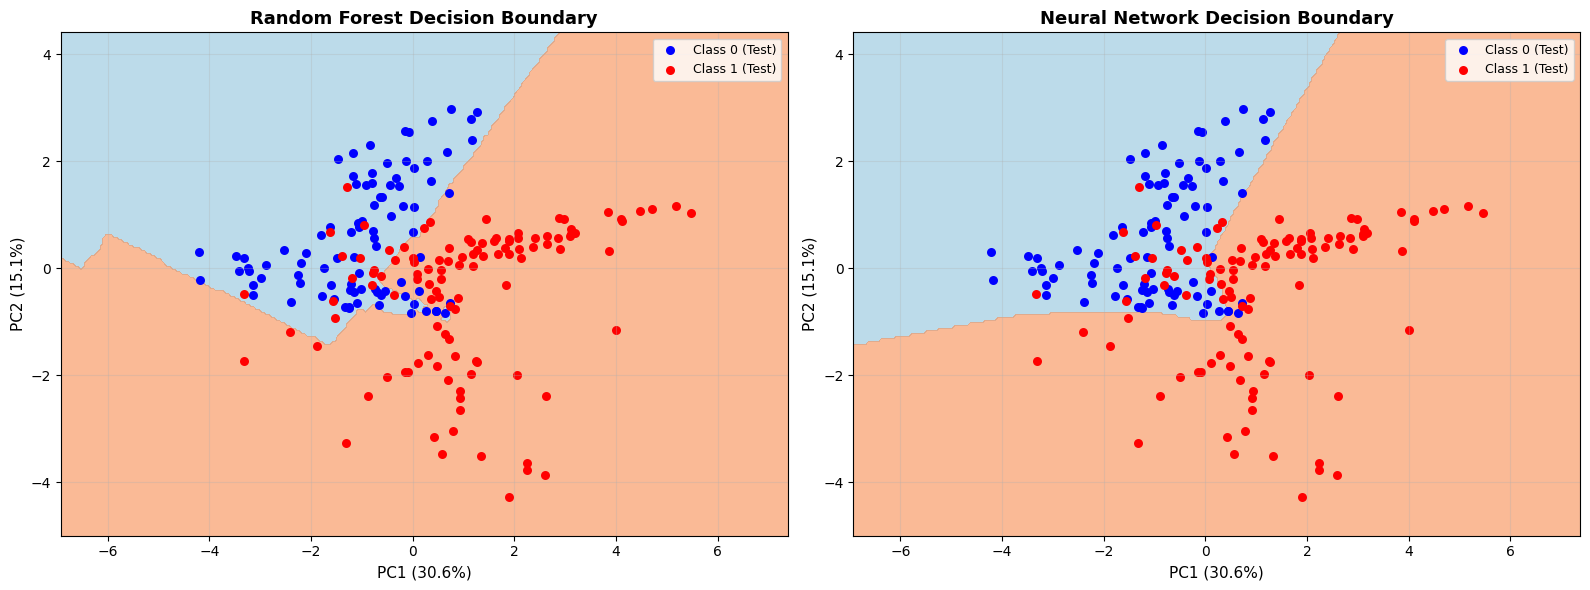


Decision Boundary Visualization Complete!
- Blue regions = Model predicts Class 0
- Red regions = Model predicts Class 1
- Circle markers = Training data
- X markers = Test data


In [77]:
from sklearn.decomposition import PCA
import numpy as np

# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.1%}")

# Create a mesh for decision boundary
h = 0.05  # step size in the mesh
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Get predictions from both models on the mesh
# We need to transform mesh points back to original 10D space
mesh_points = np.c_[xx.ravel(), yy.ravel()]
mesh_points_original = pca.inverse_transform(mesh_points)

# Random Forest predictions
rf_mesh_pred = rf_model.predict(mesh_points_original)

# PyTorch model predictions
with torch.no_grad():
    mesh_tensor = torch.FloatTensor(mesh_points_original).to(X_train_tensor.device)
    mesh_outputs = model(mesh_tensor)
    dl_mesh_pred = torch.argmax(mesh_outputs, dim=1).cpu().numpy()

# Create side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Random Forest Decision Boundary
rf_mesh_pred_reshaped = rf_mesh_pred.reshape(xx.shape)
axes[0].contourf(xx, yy, rf_mesh_pred_reshaped, levels=np.linspace(0, 1, 3), 
                 cmap='RdYlBu_r', alpha=0.6)
axes[0].scatter(X_test_pca[y_test == 0, 0], X_test_pca[y_test == 0, 1], 
               c='blue', s=20,label='Class 0 (Test)', linewidths=2)
axes[0].scatter(X_test_pca[y_test == 1, 0], X_test_pca[y_test == 1, 1], 
               c='red', s=20, label='Class 1 (Test)', linewidths=2)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0].set_title('Random Forest Decision Boundary', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot Neural Network Decision Boundary
dl_mesh_pred_reshaped = dl_mesh_pred.reshape(xx.shape)
axes[1].contourf(xx, yy, dl_mesh_pred_reshaped, levels=np.linspace(0, 1, 3), 
                 cmap='RdYlBu_r', alpha=0.6)
axes[1].scatter(X_test_pca[y_test == 0, 0], X_test_pca[y_test == 0, 1], 
               c='blue', s=20, label='Class 0 (Test)', linewidths=2)
axes[1].scatter(X_test_pca[y_test == 1, 0], X_test_pca[y_test == 1, 1], 
               c='red', s=20, label='Class 1 (Test)', linewidths=2)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[1].set_title('Neural Network Decision Boundary', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDecision Boundary Visualization Complete!")
print("- Blue regions = Model predicts Class 0")
print("- Red regions = Model predicts Class 1")
print("- Circle markers = Training data")
print("- X markers = Test data")


## Summary: ML vs DL Comparison

### Machine Learning (Random Forest)
- **Feature Engineering**: We passed raw features directly
- **Model Training**: Simple, non-iterative fitting
- **Inference**: One-shot prediction
- **Explainability**: Feature importances are interpretable

### Deep Learning (Neural Network)
- **Representation Learning**: Model learns hierarchical features automatically
- **Model Training**: Iterative optimization over epochs with backpropagation
- **Gradient-Based**: Uses gradients (backward pass) to update weights
- **Scalability**: Better with large datasets and complex patterns

Both achieved high accuracy on this toy problem, but Deep Learning excels with larger, more complex data (images, sequences, text).